In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as wr
wr.filterwarnings('ignore')

## Task 1- DATA LOADING AND EXPLORATION

In [3]:
df=pd.read_csv("Housing.csv")

### Displaying the first 10 rows from the dataset.

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### The dataset contains following features/columns:
- Area
- Bathrooms
- Bedrooms
- Stories
- Mainroad
- Parking
- Prefare
- Guestroom
- Basement
- Hotwater Heating
- Air Conditioning
- Furnishing Status
- Price(Target variable)

In [5]:
df.shape

(545, 13)

### There are 545 rows and 13 columns in the Housing csv.

In [10]:
# Target variable
y=df["price"]
# Feature variable
X=df.drop("price",axis=1)

### Checking for missing values in each column

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [11]:
#Check for missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Result: No missing values found

### Since each column has 0 value which means the dataset contains zero missing values overall.

## Task 2- DATA CLEANING

### 1. Handle missing value

### In the above Code cell, missing values is checked using df.isnull().sum(). As NO MISSING VALUE FOUND in the dataset, therefore, no missing value handling is required for this specific dataset

### 2. Removing duplicates

In [13]:
df=df.drop_duplicates()

### 3. Converting any categorical columns into numerical values using One Hot Encoding.

In [16]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols=['mainroad','guestroom','basement','hotwaterheating',
                  'airconditioning','prefarea','furnishingstatus']
encoder=OneHotEncoder(drop='first',sparse_output=False)
encoded_data=encoder.fit_transform(df[categorical_cols])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(categorical_cols))

df_encoded=pd.concat([df.drop(columns=categorical_cols).reset_index(drop=True),encoded_df.reset_index(drop=True)],axis=1)
print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2           1.0   
1  12250000  8960         4          4        4        3           1.0   
2  12250000  9960         3          2        2        2           1.0   
3  12215000  7500         4          2        2        3           1.0   
4  11410000  7420         4          1        2        2           1.0   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0            0.0           0.0                  0.0                  1.0   
1            0.0           0.0                  0.0                  1.0   
2            0.0           1.0                  0.0                  0.0   
3            0.0           1.0                  0.0                  1.0   
4            1.0           1.0                  0.0                  1.0   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0           1.0  

### 4. Keeping meaningful columns for predicting price

###  All columns except Price are feature variables as they are required for predicting Price

In [17]:
X=df_encoded.drop('price',axis=1)
y=df_encoded['price']

## Task 3- MODEL BUILDING

### 1. Split the data into training and testing sets(80/20)

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
print("Training set shape: ",X_train.shape)
print("Testing set shape: ",X_test.shape)

Training set shape:  (436, 13)
Testing set shape:  (109, 13)


### 2. Train a Linear Regression model to predict house price

In [23]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

lr.fit(X_train,y_train)

In [26]:
y_pred=lr.predict(X_test)

### predicting first 5 houses

In [28]:
print(y_pred[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


### 3. Evaluating model using MAE, RMSE and R^2 SCORE

In [32]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE: ",mae)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  970043.4039201637
RMSE:  1324506.9600914386
R2:  0.6529242642153184


### 4. Training a Random Forest Regressor

In [71]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor=RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)

In [72]:
rf_regressor.fit(X_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
y_pred_rf=rf_regressor.predict(X_test)

In [74]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=root_mean_squared_error(y_test,y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)

In [75]:
comparison=pd.DataFrame({
    'Model':["Linear Regression",'Random Forest'],
    'MAE':[mae,mae_rf],
    'RMSE':[rmse,rmse_rf],
    'R2':[r2,r2_rf]
})
print(comparison)

               Model           MAE          RMSE        R2
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.016168e+06  1.398857e+06  0.612865


### Linear Regression outperformed Random Forest on this dataset,achieving a higher R^2 and lower MAE and RMSE. This may be due to the small dataset size(545 rows), where Random Forest with default hyperparameters did not generalize as well. 
### Tuning Random Forest hyperparameters did not improve performance, therefore, Linear Regression is better suited for this dataset size.

## Task 4- VISUALIZATION

###  Chart 1: Histogram showing the distribution of house prices

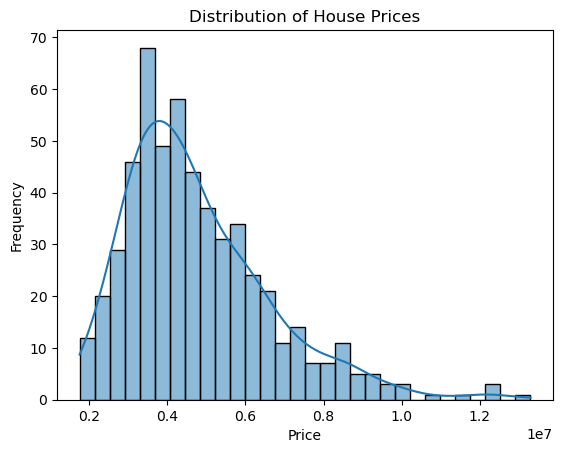

In [104]:
sns.histplot(df["price"],bins=30,kde=True,palette="Set3")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### As per the histogram, a small number of properties were significantly more expensive than the rest as the distribution of house price is right-skewed.

### Chart 2: Correlation heatmap showing which features relate most to price

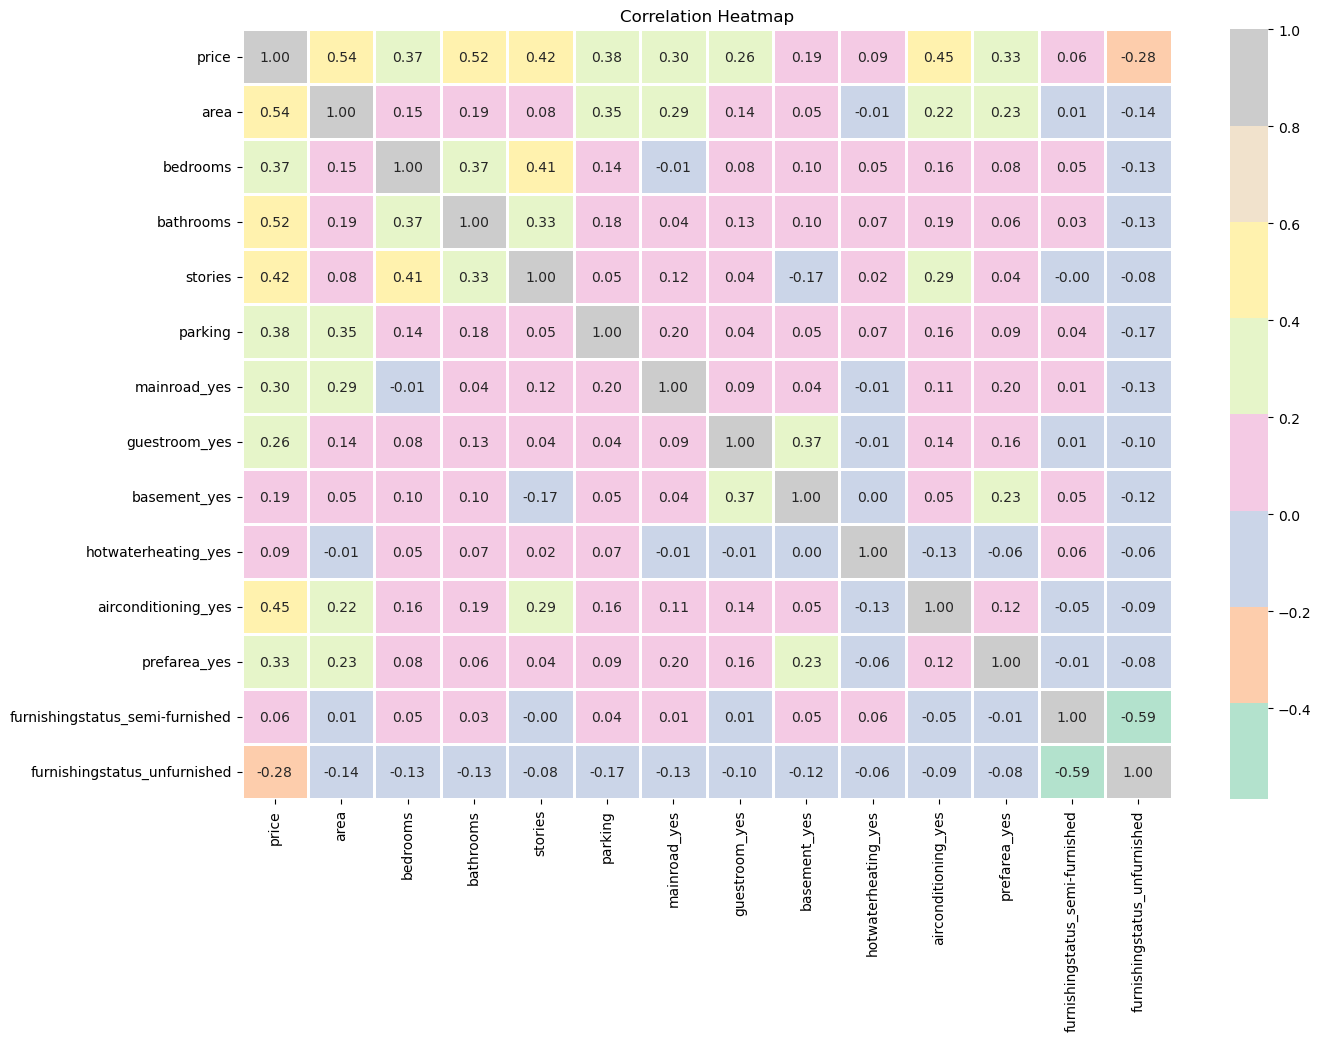

In [100]:
plt.figure(figsize=(15,10))
sns.heatmap(df_encoded.corr(),annot=True,fmt='.2f',cmap='Pastel2',linewidths=2)
plt.title('Correlation Heatmap')
plt.show()

### Price is most influenced by Area, Air Conditioning, Bathrooms and Stories. Unfurnished houses have a negative correlation with Price.

### Chart 3: Box plot showing whether the  availability of airconditioning tend to cost more or not

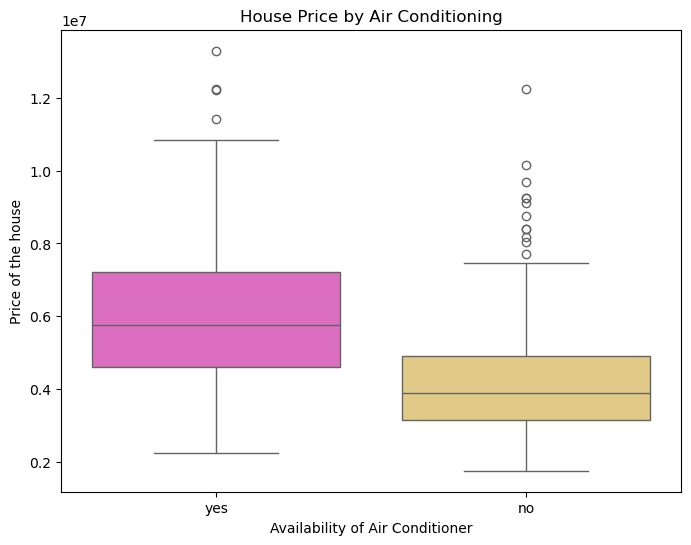

In [97]:
plt.figure(figsize=(8,6))
custom_colour=["#ed5cc9","#f0d278"]
sns.boxplot(x="airconditioning",y="price",data=df,palette=custom_colour)
plt.xlabel("Availability of Air Conditioner")
plt.ylabel("Price of the house")
plt.title("House Price by Air Conditioning")
plt.show()

### Chart 4: Swarm Plot showing whether furnished houses tend to cost more or not

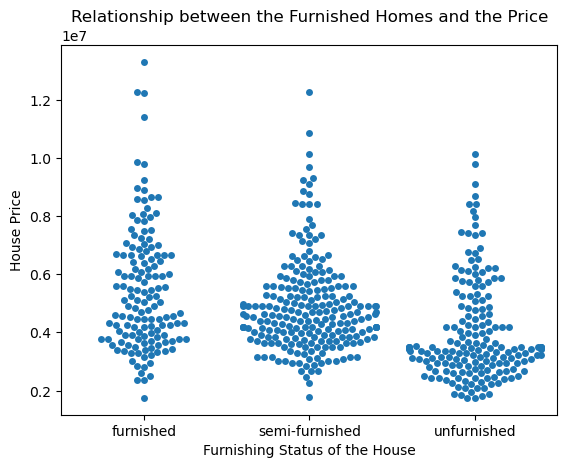

In [88]:
sns.swarmplot(x="furnishingstatus",y="price",data=df)
plt.title("Relationship between the Furnished Homes and the Price")
plt.xlabel("Furnishing Status of the House")
plt.ylabel("House Price")
plt.show()

### Furnished houses are comparatively more expensive than semi-furnished and unfurnished houses.

### Chart 5: Scatter Plot to show relationship between Area and Price

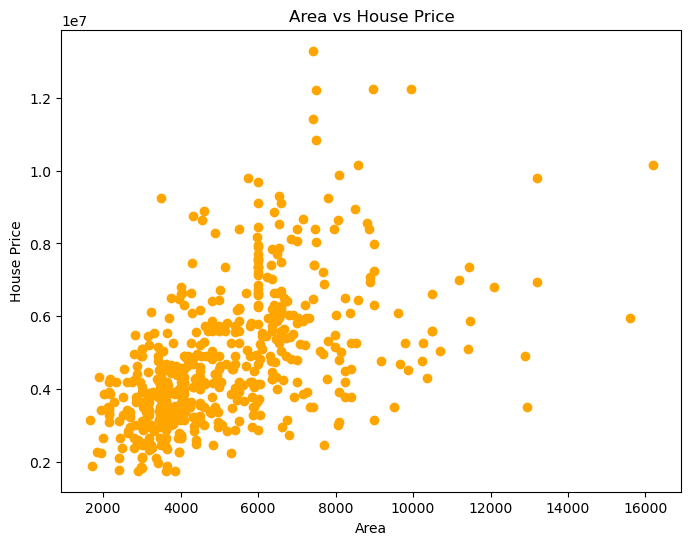

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(x="area",y="price",data=df,c="orange")
plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.show()

### The spread of points around 6000-8000 sqft represents same size houses have different prices which means that area alone doesn't determine price and other feature variables influence price as well

### Chart 6: Scatter Plot to show model performance

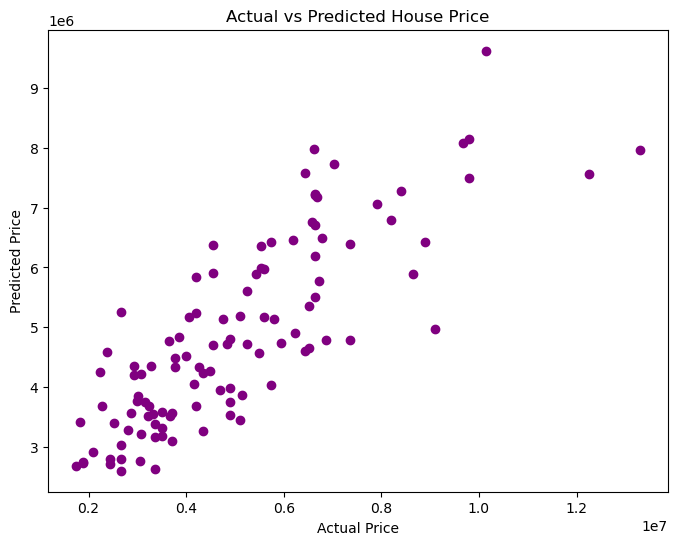

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(x=y_test,y=y_pred, c="purple")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

### The overall trend is good, the model is generally predicting in the right direction. However, the points are quite scattered which confirms the $R^2$ score of 0.65 is only moderate. The model struggles the most at higher prices as the predictions are inconsistent due to the underrepresentation of expensive houses in the trainig data.

## Task 5- INSIGHTS & SUMMARY

### According to the correlation heatmap, Area(0.54 correlation), Bathrooms(0.52), Stories(0.42) and the availability of air conditioning(0.45) influenced the prices of the house the most. Out of all the features, Area dominated the affect on the price of the house as it had +0.54 correlation with price. <br>
### The Linear Regression model achieved  $R^2$ score of 0.65 i.e. the model is able to explain 65% of variation in house prices and provides reasonably accurate prediction. <BR>
### The details that suprisied me was the $R^2$ score of Random Forest model(0.611), even when the hyperparameters were used the $R^2$ score decreased which occured due to the small size of dataset. Also, air conditioning had a stronger relationship with house price than the number of bedrooms. As per the histogram, a small number of properties were significantly more expensive than the rest as the distribution of house price is right-skewed. Furnished houses are comparatively more expensive than semi-furnished and unfurnished houses. <BR>
### Based on the visualisations, a real estate business should focus on marketing larger homes with premium amenities like air conditioning and better furnishing. 